In [25]:

import pandas as pd

# Cargar datos originales
df = pd.read_csv('./data/titanic.csv')

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [26]:
# Copia del DataFrame original para no modificar df directamente
import pandas as pd
import numpy as np

# 1) Cargar datos originales
df = pd.read_csv('./data/titanic.csv')

df.head()
df.info()

# 2) Imputar Age con la MEDIANA
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

# 3) Imputar Embarked con la MODA
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 4) Eliminar columna Cabin (demasiados nulos)
df.drop('Cabin', axis=1, inplace=True)

# 5) Eliminar columnas que no usaremos: PassengerId, Name, Ticket
df.drop('Name', axis=1, inplace=True)
df.drop('Ticket', axis=1, inplace=True)
df.drop('PassengerId', axis=1, inplace=True)

# 6) Verificar resultado
print(f"Después de limpiar df: {df.shape[0]} filas y {df.shape[1]} columnas.")
print(df.isnull().sum())

# 7) Guardar datos limpios en ./data/titanic_clean.csv
df.to_csv('./data/titanic_clean.csv', index=False)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Después de limpiar df: 891 filas y 8 columnas.
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64


C:\Users\Alicia Vaca\AppData\Local\Temp\ipykernel_25824\608352157.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(median_age, inplace=True)


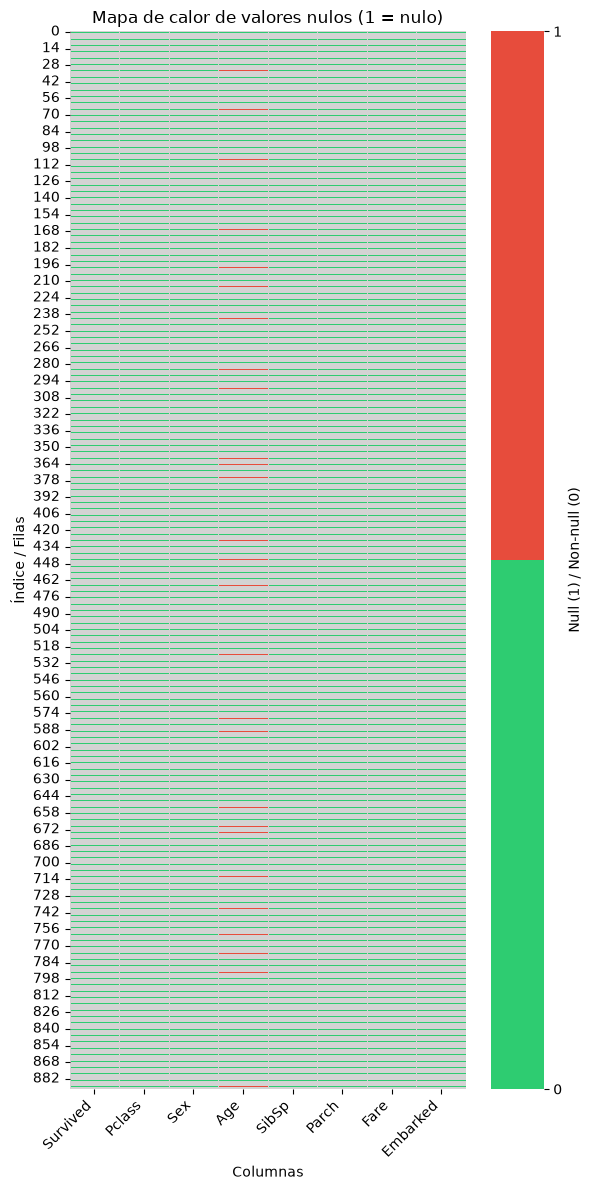

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una máscara booleana: True donde hay nulos en el df original
mask_null = df.isnull()

# Configurar figura (tamaño se adapta al número de filas/columnas)
plt.figure(figsize=(min(20, 0.5 * df.shape[1] + 2),
                    min(12, 0.3 * df.shape[0] + 2)))

# Dibujar mapa de calor: 1 = nulo, 0 = no nulo
sns.heatmap(
    mask_null.astype(int),
    cmap=sns.color_palette(["#2ecc71", "#e74c3c"]),  # verde = no nulo, rojo = nulo
    cbar_kws={'ticks': [0, 1], 'label': 'Null (1) / Non-null (0)'},
    linewidths=0.5,
    linecolor='lightgray',
    annot=False
)

plt.title('Mapa de calor de valores nulos (1 = nulo)')
plt.xlabel('Columnas')
plt.ylabel('Índice / Filas')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()